# Step 1: Machine Learning Models

## Task 1.1 — Load and Explore

- [ ] Load the dataset with pandas and print the first few rows
- [ ] Check the shape (number of rows and columns)
- [ ] Check for missing values — fill or drop them
- [ ] Check class balance: are there roughly equal numbers of each label?
- [ ] If one class has far more samples than the other, note this and use F1-score as your main metric

In [106]:
import pandas as pd
import matplotlib.pyplot as plt

In [126]:
# Load the training data from a CSV file
df = pd.read_csv("data/train.csv")

In [115]:
# Display the first few rows of the DataFrame
print(df.head())

   PassengerId  Survived  Pclass   Age  SibSp  Parch     Fare  Sex_male  \
0            1         0       3  22.0      1      0   7.2500      True   
1            2         1       1  38.0      1      0  71.2833     False   
2            3         1       3  26.0      0      0   7.9250     False   
3            4         1       1  35.0      1      0  53.1000     False   
4            5         0       3  35.0      0      0   8.0500      True   

   Embarked_Q  Embarked_S  
0       False        True  
1       False       False  
2       False        True  
3       False        True  
4       False        True  


In [116]:
# Display the shape of the DataFrame
print(df.shape)

(891, 10)


In [127]:
# Display summary information about the DataFrame, including data types and non-null counts
print(df.info())

# Handle missing values in the 'Age' column by filling them with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# Drop the 'Cabin' column since it has a large number of missing values and may not provide useful information for the model
df = df.drop(columns=['Cabin'])

# Handle missing values in the 'Embarked' column by filling them with the mode (most frequent value)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64


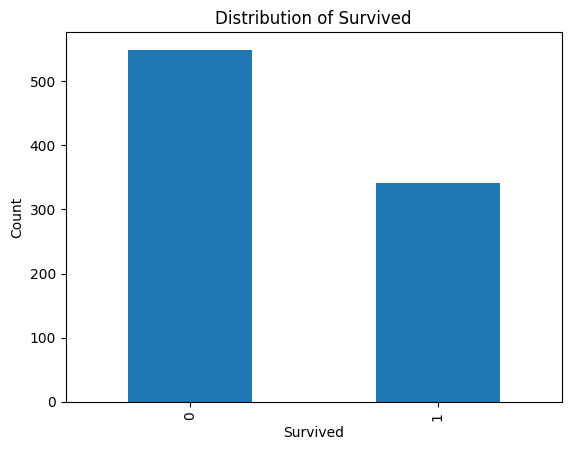

In [131]:
# Display the distribution as percentages
print(df['Survived'].value_counts(normalize=True))

# Visualize the distribution of the 'Survived' column using a bar plot
df['Survived'].value_counts().plot(kind='bar')
plt.xlabel('Survived')
plt.ylabel('Count')
plt.title('Distribution of Survived')
plt.show()

##### The dataset is mildly imbalanced — 62% did not survive, and 38% survived. I will use the F1 Score as my primary metric to account for this.

In [129]:
# Identify categorical columns in the DataFrame
print(df.select_dtypes(include=['object']).columns)

# Drop 'Name', 'Ticket' and 'PassengerId' columns.
df = df.drop(columns=['Name', 'Ticket', 'PassengerId'])

# Convert categorical variables into dummy/indicator variables
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='object')


### Task 1.2 — Prepare the Data

---
- [ ] Separate features (X) and label (y)
- [ ] Split the data into training (80%) and testing (20%) sets using `random_state=42`
---

In [88]:
# Separate features (X) and label (y)
X = df.drop(columns='Survived')  # Everything except the label
y = df['Survived']  # Only the label

In [ ]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Task 1.3 — Train and Compare Models

---
- [ ] Train at least 3 models: e.g. Logistic Regression, Random Forest, KNN
- [ ] For each model report: accuracy, precision, recall, F1-score
- [ ] Plot a confusion matrix for each model
- [ ] Put all results in one summary table and choose the best model — explain your choice
---

In [109]:
from sklearn.linear_model import LogisticRegression # Logistic Regression
from sklearn.ensemble import RandomForestClassifier # Random Forest
from sklearn.neighbors import KNeighborsClassifier # K-Nearest Neighbors

from sklearn.pipeline import Pipeline # For creating a pipeline of transformations and model
from sklearn.preprocessing import StandardScaler # For feature scaling

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score # Evaluation metrics

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay # For confusion matrix visualization

Accuracy: 0.8044692737430168
Precision: 0.7746478873239436
Recall: 0.7432432432432432
F1 Score: 0.7586206896551724


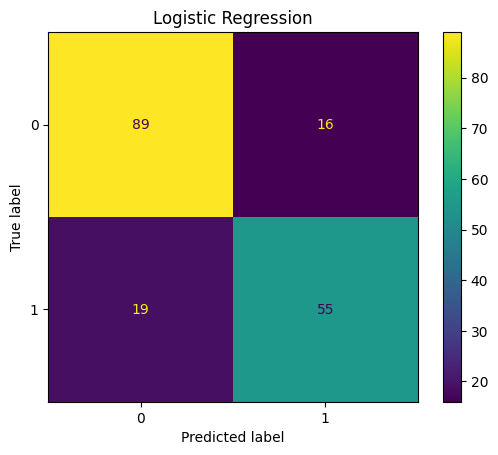

In [112]:
# Create a pipeline for Logistic Regression
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),  # Feature scaling
    ('model', LogisticRegression(random_state=42)) # Logistic Regression model
])
# Fit the pipeline to the training data
lr_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred_lr = lr_pipeline.predict(X_test)

# Evaluate the model using accuracy, precision, recall, and F1 score
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall:", recall_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

# Visualize the confusion matrix for Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(cm_lr).plot()
plt.title("Logistic Regression")
plt.show()

Accuracy: 0.8212290502793296
Precision: 0.8088235294117647
Recall: 0.7432432432432432
F1 Score: 0.7746478873239436


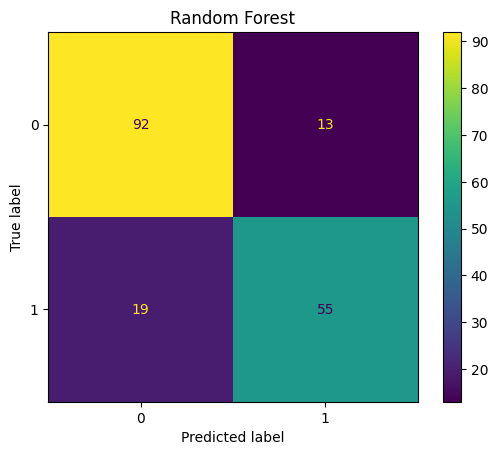

In [113]:
# Train a random forest classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
# Fit the model to the training data
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model's performance using accuracy, precision, recall, and F1 score
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

# Visualize the confusion matrix for Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf).plot()
plt.title("Random Forest")
plt.show()

Accuracy: 0.8044692737430168
Precision: 0.782608695652174
Recall: 0.7297297297297297
F1 Score: 0.7552447552447552


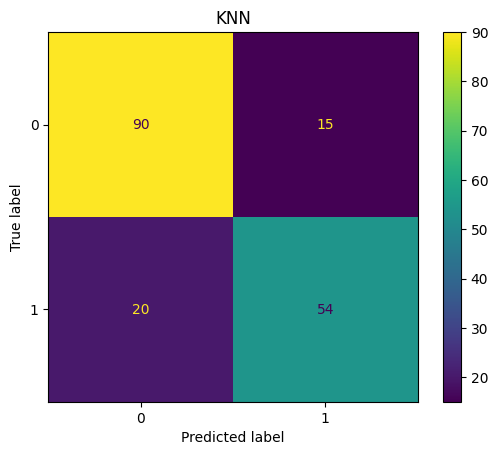

In [132]:
# Train a K-Nearest Neighbors classifier with feature scaling
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()), # Feature scaling
    ('model', KNeighborsClassifier(n_neighbors=5))  # KNN model
])
# Fit the pipeline to the training data
knn_pipeline.fit(X_train, y_train)

# Make predictions on the test set
y_pred_knn = knn_pipeline.predict(X_test)

# Evaluate the model using accuracy, precision, recall, and F1 score
print("Accuracy:", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall:", recall_score(y_test, y_pred_knn))
print("F1 Score:", f1_score(y_test, y_pred_knn))

# Visualize the confusion matrix for K-Nearest Neighbors
cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn).plot()
plt.title("KNN")
plt.show()

In [139]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'KNN'],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn)
    ],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_knn)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_knn)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_knn)
    ]
})

print(results)

                 Model  Accuracy  Precision    Recall  F1 Score
0  Logistic Regression  0.804469   0.774648  0.743243  0.758621
1        Random Forest  0.821229   0.808824  0.743243  0.774648
2                  KNN  0.804469   0.782609  0.729730  0.755245


## Model Selection — Best Model: Random Forest

Random Forest was selected as the best model, achieving the highest accuracy (82.1%), 
precision (0.809), and F1 score (0.775) among all three models. Since the dataset has 
a mild class imbalance, the F1 score is the most important metric, and Random Forest 
leads in this regard. Logistic Regression was a close second, while KNN ranked last 
across all metrics.